# Create an animation of the deconvolved gene profiles
February 26, 2024

Can we create a way to threshold the PTR values and create a movie of the the deconvolved gene profiles.

The Goal: Identify an easy way to characterize a gene's cell cycling chromatin. Perhaps a movie or a large set of these genes will give us a good idea on how quantify/simplify these measures.


In [6]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
from cc_src.chromatin_model import load_chromatin_model_from_disk

chromatin_dir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'
#gene_name = 'CLB2'

#chromatin_model = load_chromatin_model_from_disk(gene_name, chromatin_dir)

In [161]:
from src.heatmap_animator import FHeatmapAnimator

animator = FHeatmapAnimator(chromatin_model)

In [195]:
animator.create_animation('output/clb2.gif')

Creating directory: tmp/frames...Directory exists. Skipping.


In [196]:
from IPython.display import Image
import time

gif_path = 'output/clb2.gif'
gif_url = f"{gif_path}?{time.time()}" # bypass cached image
Image(url=gif_url) # display image


In [2]:
gene_name = 'SSK22'
chromatin_model = load_chromatin_model_from_disk(gene_name, chromatin_dir)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.
todo: Trying a regularization term that will keep f consistent across timepoints


In [205]:
chromatin_model.create_deconvolution_bins()

In [210]:
G = chromatin_model.G.copy()

G_sums = G.sum(axis=1)

In [211]:
# Ensure that the read count within the window
# for all timepoints are equal, SSK22 will present a fixed chromatin deconvolution profile.

copy_number_normalized_G = G.copy()

for row in range(G.shape[0]):
    normalized = G[row] / G_sums[row] * 1000.
    copy_number_normalized_G[row] = normalized


In [215]:
chromatin_model.G_old = chromatin_model.G
chromatin_model.G = copy_number_normalized_G

In [216]:
chromatin_model.deconvolve()

Deconvolving with gamma=0.006, gamma_prime=0
Deconvolved in : 00:01:25.02
The fitting norm is 4.36, the smoothing norm is: 8.68


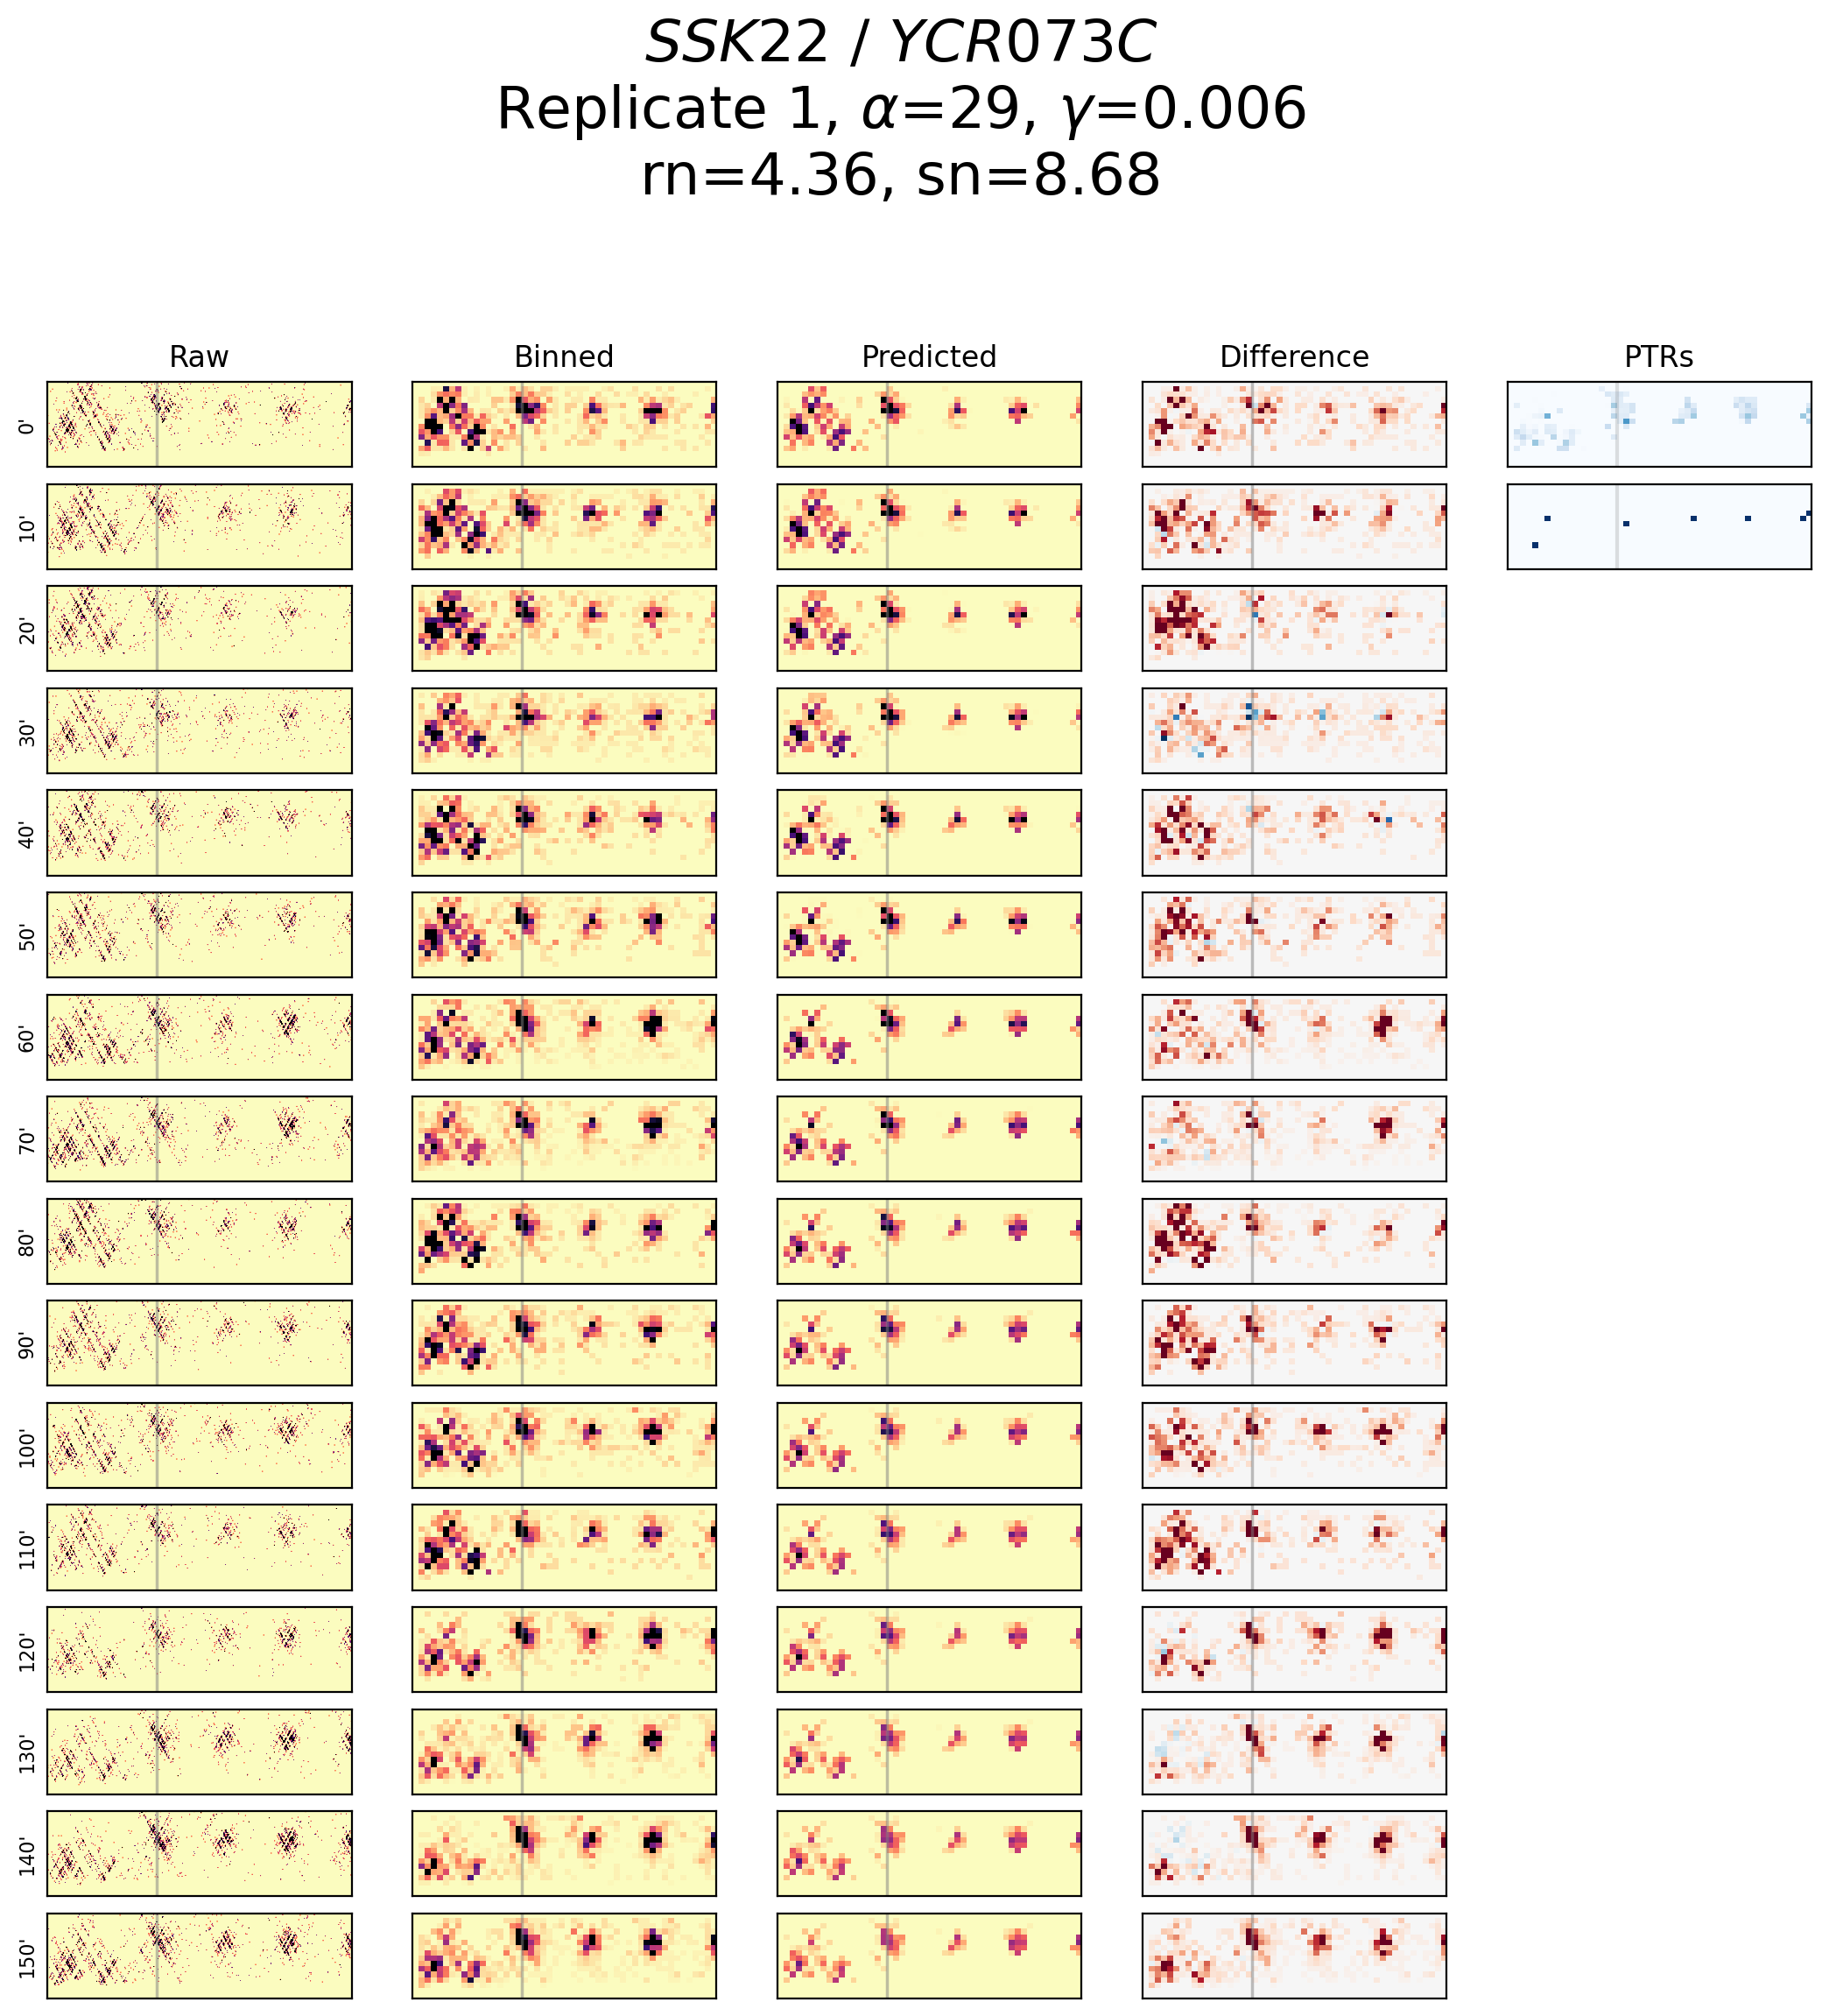

In [221]:
chromatin_model.compute_ptr()
fig = chromatin_model.plot_prediction_comparison()

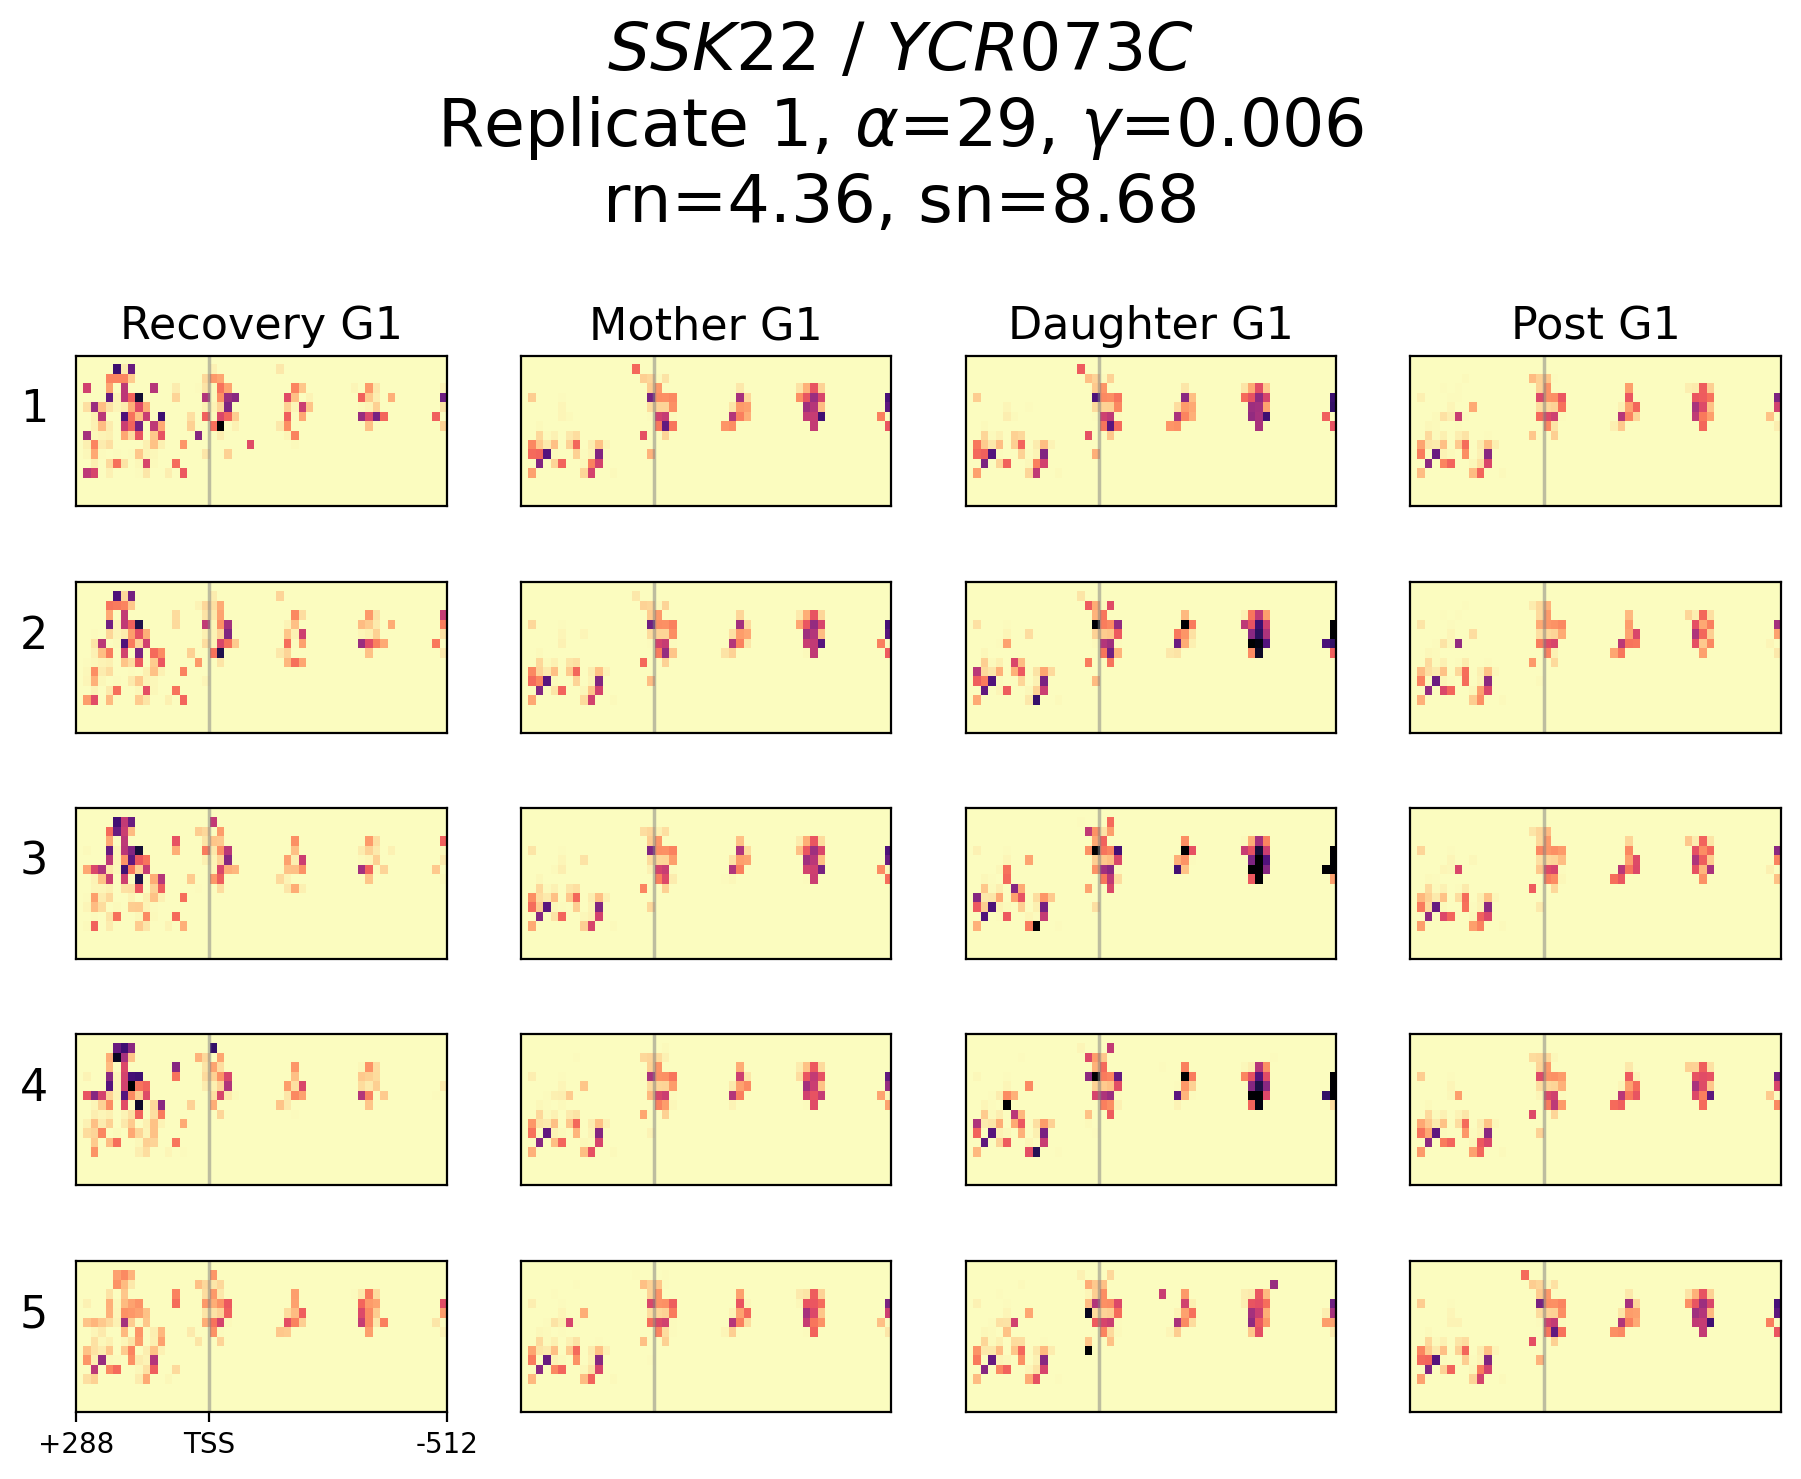

In [218]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped()

In [222]:
# let's compare to the old, unnormalized deconvolution profile:
chromatin_model.create_deconvolution_bins()
chromatin_model.deconvolve()
chromatin_model.compute_ptr()

Deconvolving with gamma=0.006, gamma_prime=0
Deconvolved in : 00:01:25.03
The fitting norm is 4.38, the smoothing norm is: 8.46


(0.0, 500.0)

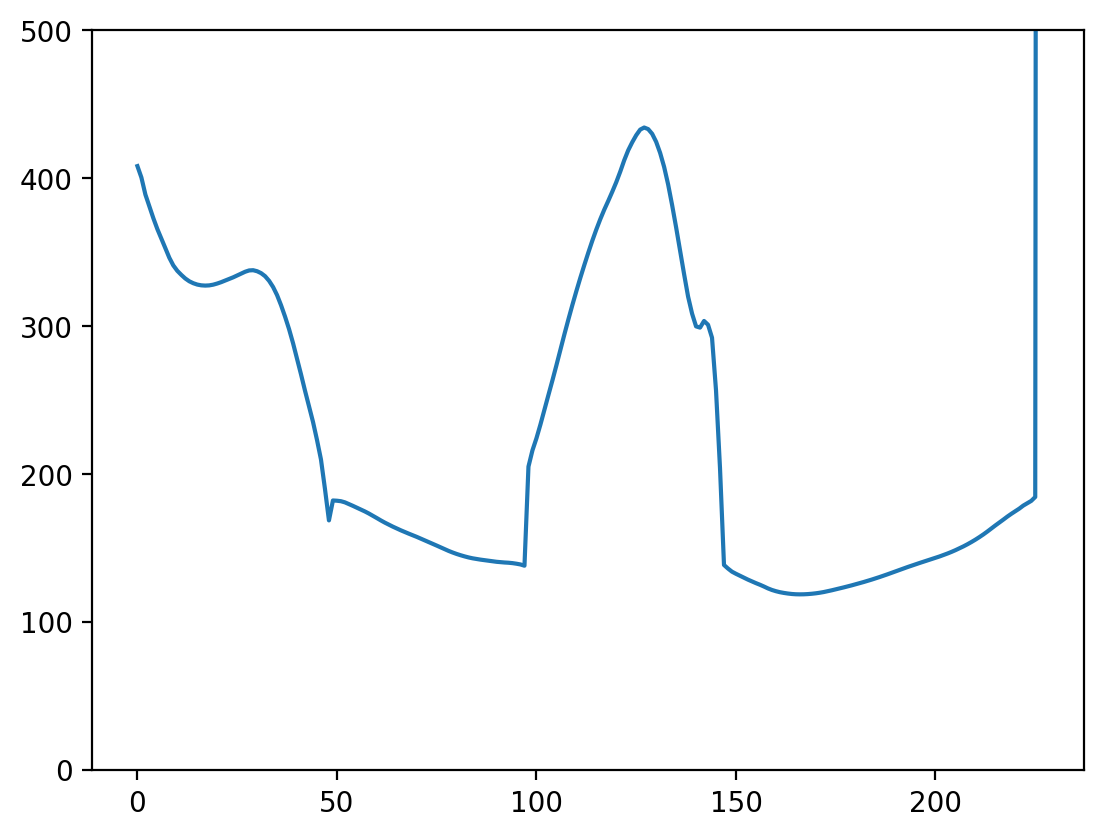

In [231]:
# What if we were to constrain each F to be equal in sum?

f = chromatin_model.deconvolved_f()
f_sums = np.sum(f, axis=1)
plt.plot(f_sums)
plt.ylim(0, 500)

In [29]:
# let's compare to the old, unnormalized deconvolution profile:
chromatin_model.create_deconvolution_bins()
chromatin_model.deconvolve(verbose=True)
chromatin_model.compute_ptr()

AssertionError: 

In [27]:
m, u = f.shape
mean_row = (np.sum(f, axis=0) / m).reshape(1, u)
ones_column = np.ones((m, 1))
f_mean_diff = f - ones_column@mean_row


np.sum(f_mean_diff * f_mean_diff) * 0.001

349.2200933414619

(0.0, 500.0)

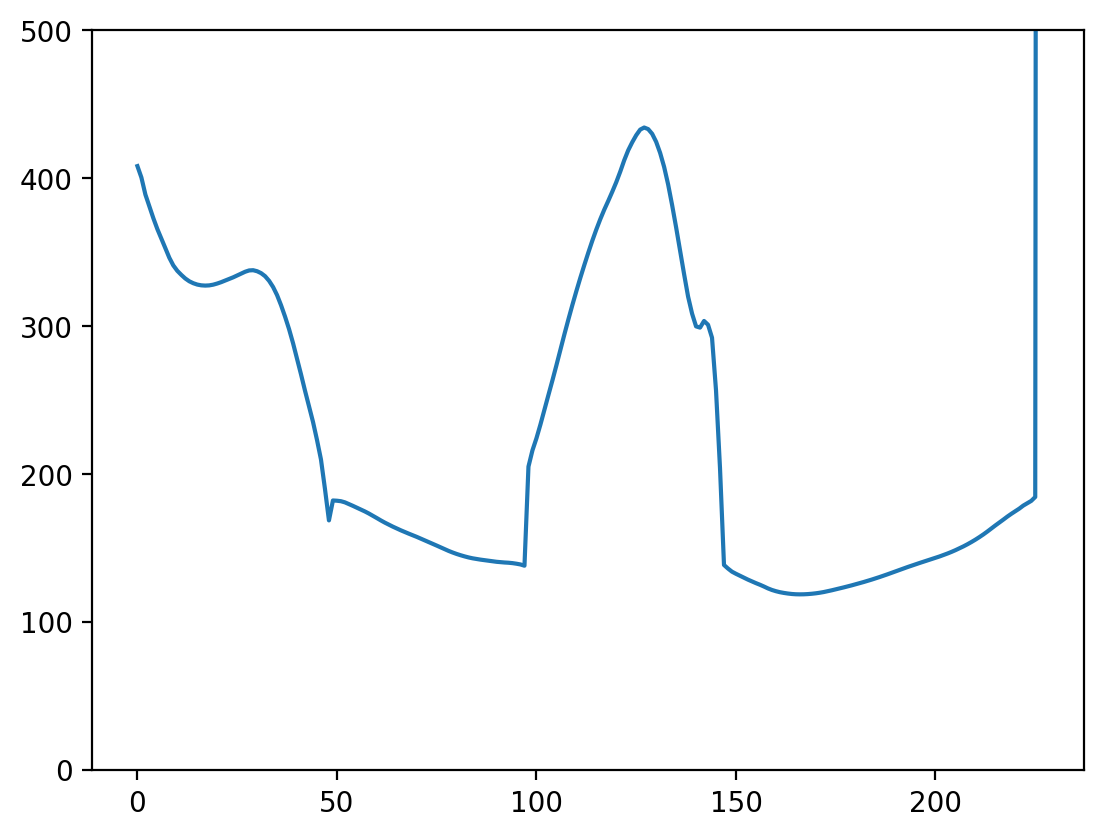

In [7]:
# Adding a regularization term that will attempt to keep the rows in f similar in value to
# one another.

f = chromatin_model.deconvolved_f()
f_sums = np.sum(f, axis=1)
plt.plot(f_sums)
plt.ylim(0, 500)

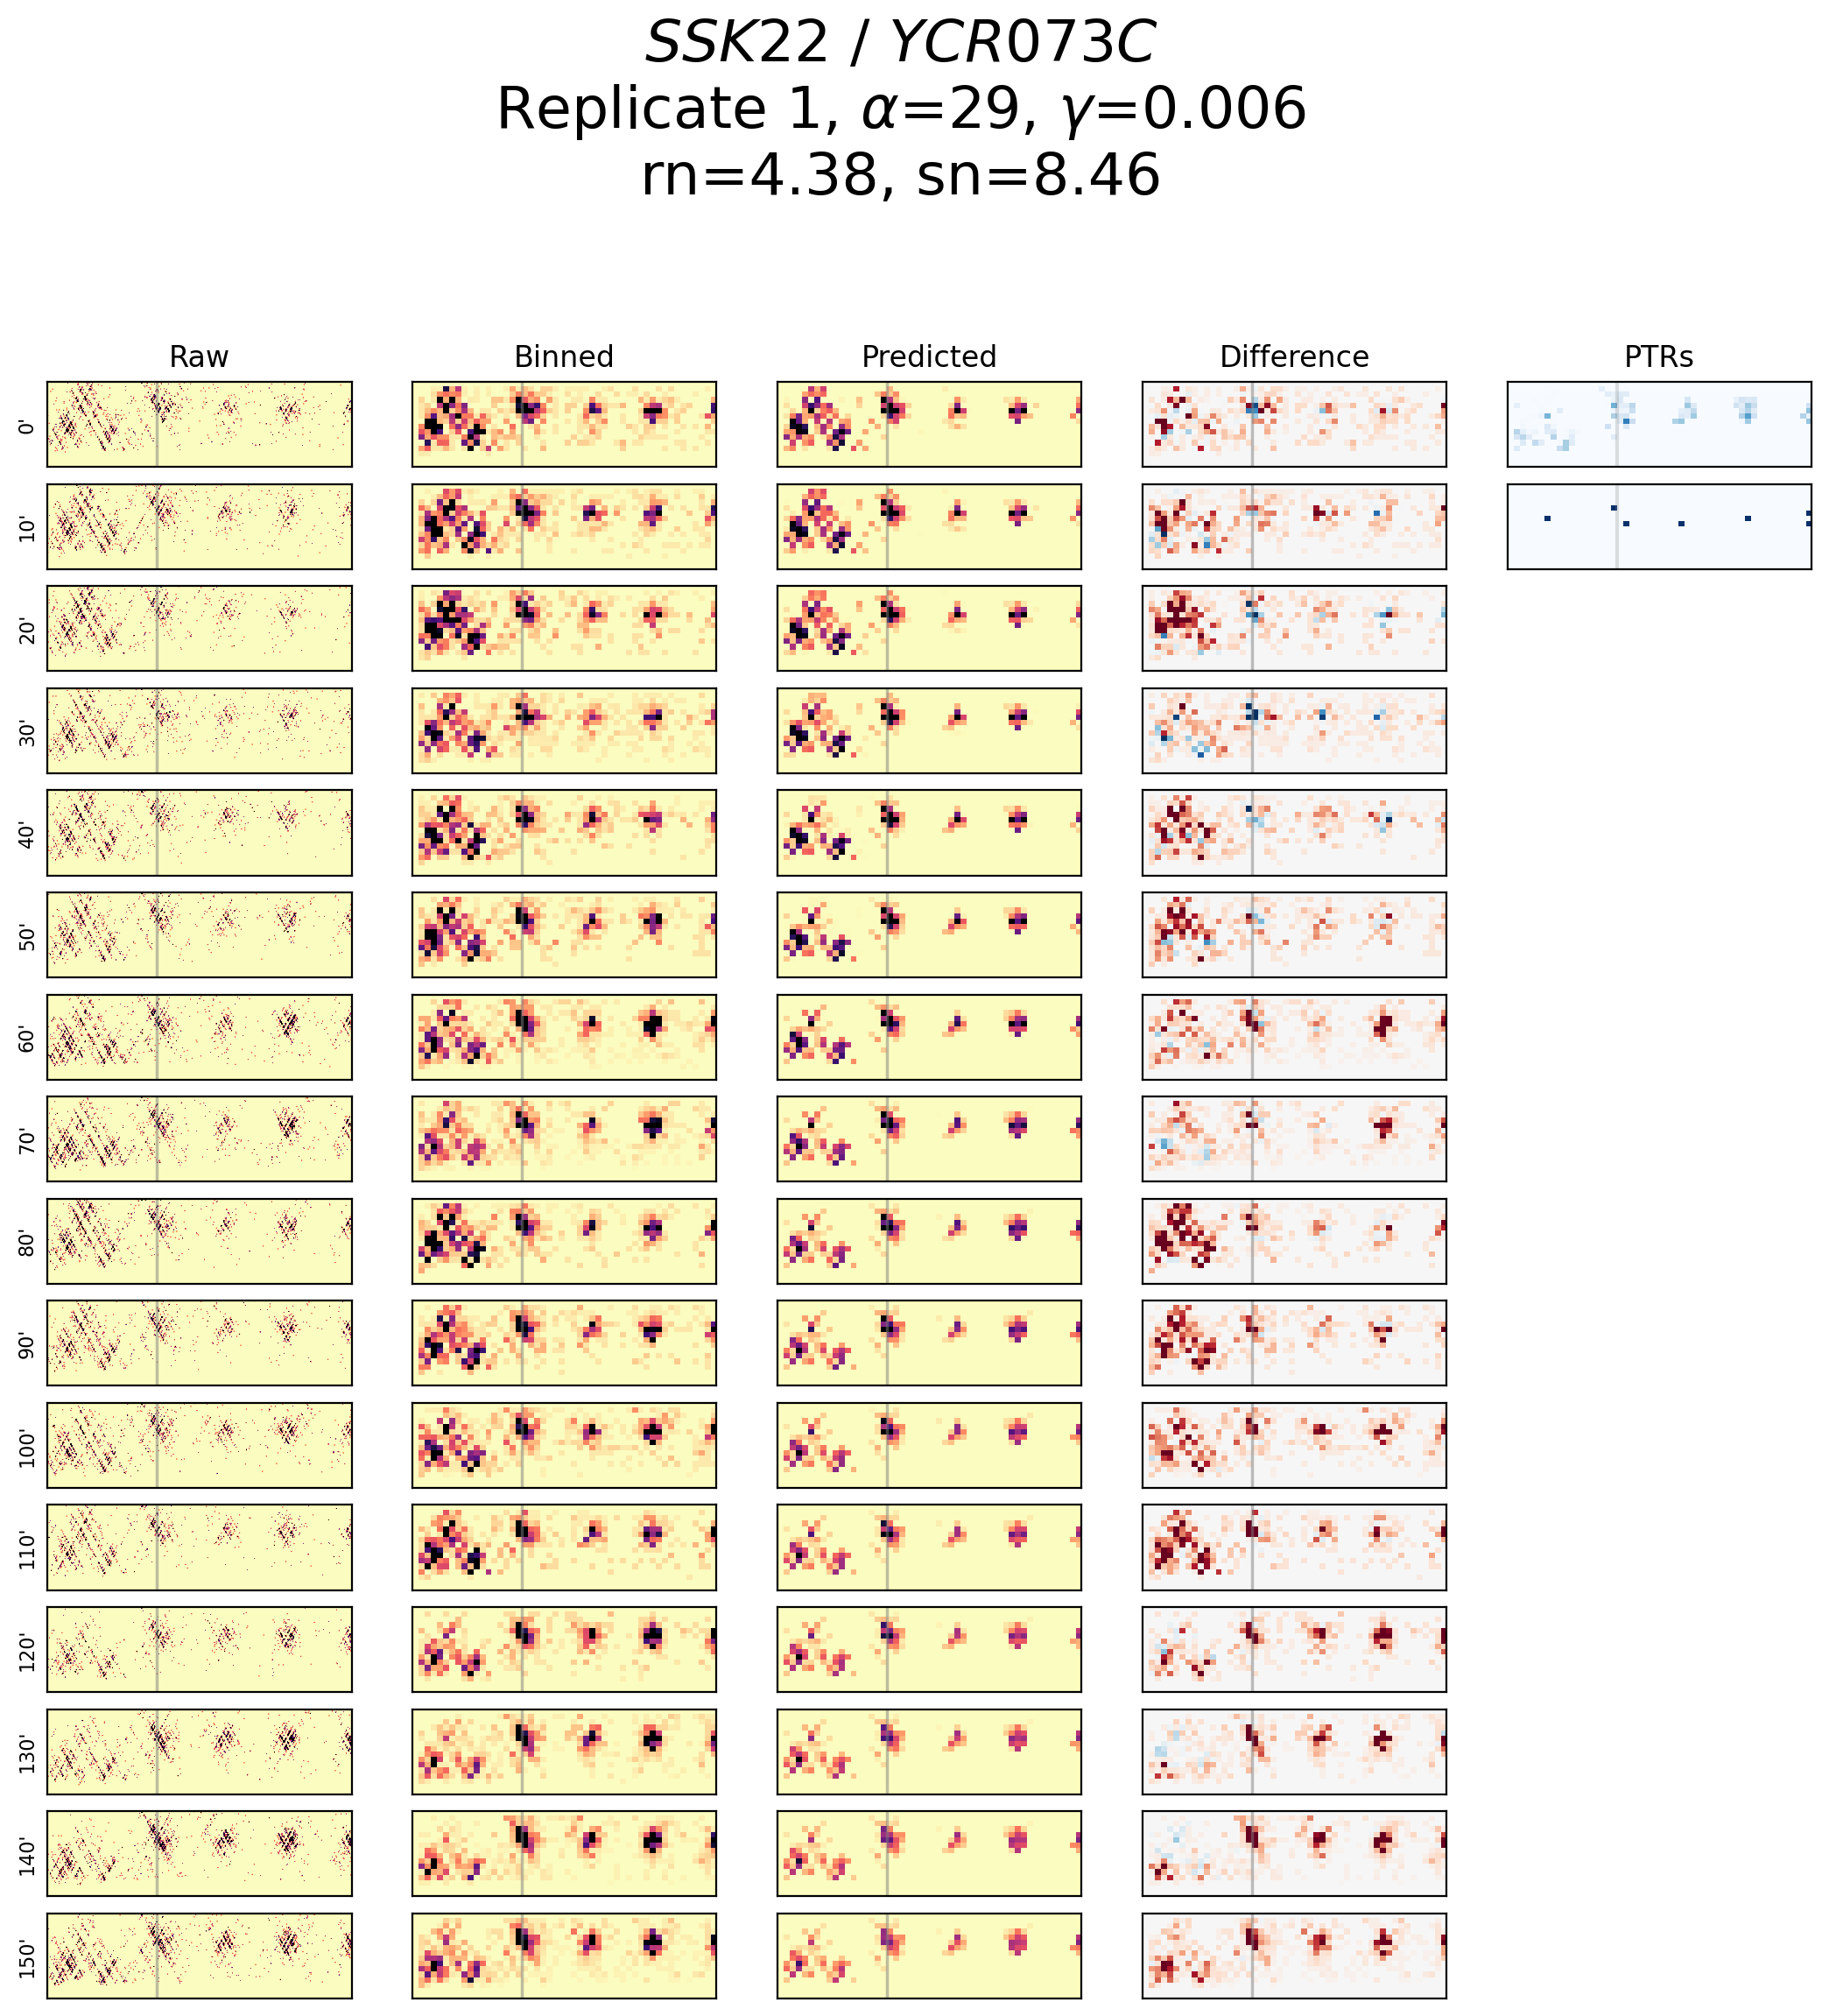

In [223]:
chromatin_model.compute_ptr()
fig = chromatin_model.plot_prediction_comparison()

In [198]:
animator.create_animation('output/ssk22.gif')

Creating directory: tmp/frames...Directory exists. Skipping.


In [199]:
gif_path = 'output/ssk22.gif'
gif_url = f"{gif_path}?{time.time()}" # bypass cached image
Image(url=gif_url) # display image